# Q13 - Full ML-flow for HR_Employee_data :O

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Load the dataset
# Read the data from the specified Excel file verbatim
df = pd.read_excel("Datasets/hr_employee_data.xlsx")

# 2. Data Preprocessing
# Drop any rows with missing values to ensure the model trains properly
df = df.dropna()

# Separate the dependent variable (y) from the independent variables (X)
X = df.drop(columns=['left'])
y = df['left']

# Convert categorical text data (like department or salary level) into numerical format
X = pd.get_dummies(X, drop_first=True)

# 3. Train/Test Split
# Split the data into 80% training and 20% testing
# stratify=y ensures the proportion of 0s and 1s remains balanced in both splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Feature Scaling
# Normalize numerical features so they share a common scale (mean=0, standard deviation=1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Model Training
# Initialize and train a Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)

# 6. Evaluation
# Make predictions on the unseen test data
y_pred = model.predict(X_test_scaled)

# Display the performance metrics
print("Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.9843333333333333

Confusion Matrix:
 [[2276   10]
 [  37  677]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      2286
           1       0.99      0.95      0.97       714

    accuracy                           0.98      3000
   macro avg       0.98      0.97      0.98      3000
weighted avg       0.98      0.98      0.98      3000



### Summary of the flow

***Preprocessing*** 

We start of with preprocession, the dataset is loaded in and removes
"null" values. Categorical columns such as positions and salary level are converted 
into numerical columns by using "pd.get_dummies()". This is to allow the model 
to make calculations on them.

***Data splitting***

The data is split into two parts. 80% is used to train the model to recognize patterns
and 20% is kept away from the model to later test how well it actually performs on
new information. We also use "stratify=y" to keep a realistic separation av one's and
zeroe's.

***Scaling*** The algorithm is fed standardized values which pervent columns with
big values (worked hours, as an example) to take majority from colums with smaller
decimal numbers. Such as performance points.

***Training***

A "RandomForestClassifier" is trained and "class_weight='balanced'" is used as a 
saftey measure incase there are way more employees that stayed compared to eomployees
that quit. This forces the model to attach equal weight to both groups.

***Evaluation***

The result isn't only measured in the overall accuary, but also via a "confusion matrix"
and a "classification report" that in detail shows the models ability to specifically 
identify the employees that leave the company with one's (1) and those employees
who stay with the company, with zero's (0).

# Q15 - MNIST

Loading MNIST dataset... (this may take a few seconds on the first run)
Fitting scaler and training model...
Model training complete!



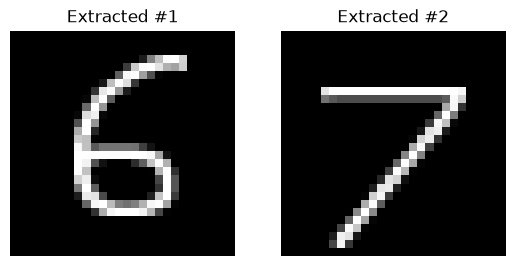

Predicted digits: [np.uint8(6), np.uint8(7)]


In [ ]:
from scipy.ndimage import center_of_mass
import math
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesClassifier


# ==========================================
# STEP 1: Load MNIST Data & Train Model
# ==========================================
print("Loading MNIST dataset... (this may take a few seconds on the first run)")

# Fetch dataset from OpenML
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

# Standard is 10k, but I had to remove the limit for my image. So it's training on 70k handwritting styles
X = mnist["data"]
y = mnist["target"].astype(np.uint8)

print("Fitting scaler and training model...")

# Standardize feature values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train the ExtraTreesClassifier model
model = ExtraTreesClassifier(n_estimators=100, random_state=42)
model.fit(X_scaled, y)

print("Model training complete!\n")


# ==========================================
# STEP 2: Preprocess & Predict Custom Image
# ==========================================
def predict_digits_from_image(image_path, model, scaler):
    # 1. Read image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image at path: {image_path}")

    # 2. Invert colors (black stroke on white bg -> white stroke on black bg)
    img_inverted = cv2.bitwise_not(img)

    # 3. Binary threshold
    _, thresh = cv2.threshold(img_inverted, 127, 255, cv2.THRESH_BINARY)

    # 4. Thicken thin Paint lines using dilation
    kernel = np.ones((3, 3), np.uint8)
    thresh = cv2.dilate(thresh, kernel, iterations=2)

    # 5. Find contours to separate digits
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[0])

    predictions = []

    for idx, contour in enumerate(contours):
        x, y, w, h = cv2.boundingRect(contour)

        if w > 5 and h > 5:
            # Crop exact digit box
            digit_crop = thresh[y:y+h, x:x+w]

            # Fit inside a 20x20 square while preserving aspect ratio
            if w > h:
                new_w = 20
                new_h = int(round(h * (20.0 / w)))
            else:
                new_h = 20
                new_w = int(round(w * (20.0 / h)))

            digit_resized = cv2.resize(digit_crop, (new_w, new_h), interpolation=cv2.INTER_AREA)

            # Place the 20x20 digit inside a blank 28x28 image
            padded_digit = np.zeros((28, 28), dtype=np.uint8)
            pad_x = (28 - new_w) // 2
            pad_y = (28 - new_h) // 2
            padded_digit[pad_y:pad_y+new_h, pad_x:pad_x+new_w] = digit_resized

            # Center digit by center-of-mass (standard MNIST centering)
            cy, cx = center_of_mass(padded_digit)
            if not np.isnan(cy) and not np.isnan(cx):
                shift_x = int(round(13.5 - cx))
                shift_y = int(round(13.5 - cy))
                M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
                final_digit = cv2.warpAffine(padded_digit, M, (28, 28))
            else:
                final_digit = padded_digit

            # Visualization
            plt.subplot(1, len(contours), idx + 1)
            plt.imshow(final_digit, cmap='gray')
            plt.title(f"Extracted #{idx+1}")
            plt.axis("off")

            # Flatten, scale, predict
            digit_flattened = final_digit.reshape(1, 784)
            digit_scaled = scaler.transform(digit_flattened)
            prediction = model.predict(digit_scaled)[0]
            predictions.append(prediction)

    plt.show()
    return predictions


# ==========================================
# STEP 3: Execute Prediction
# ==========================================
image_path = "Images/67.png"  # Ensure 67.png is in the same directory as this script
results = predict_digits_from_image(image_path, model, scaler)

print("Predicted digits:", results)

### Finally done 

I had to go through alot of hops to get this stupid meme working. 
I mainly had to remove the limit in the training part from 10 000 different handwritting styles,
to 70 000. 

I also had to modify the way I wrote the 7, since I at first used a cross bar as I do with 
whenever I write a seven on pen and paper. 

Note: the 6 started getting recognized after one tweak, the 7 took way too long.